# Brain-Act v2 — Subject-Specific Whole-Brain Simulations

**Purpose:** This notebook runs subject-specific whole-brain AdEx mean-field simulations and
saves raw firing-rate (and optionally BOLD) outputs to disk.  *No analysis is performed here.*
All downstream metrics (LZc, multi-trial PCI, brain states) are computed in the companion
notebook `brain_act_full_analysis_v2.ipynb`.

---

## What you will find in this notebook

| Section | Content |
|---------|---------|
| §1 Physics | AdEx mean-field recap, choice of T = 5 ms, noise model |
| §2 Configuration | Exact parameter values, route definitions, output layout |
| §3 Dataset | Cohort listing, structural connectivity loading |
| §4 Route A | Private-noise-only simulations (α = 0) |
| §5 Route B | Full noise-gamut simulations (5 scenarios, skip-if-done logic) |
| §6 PCI Trials | Short multi-trial PCI simulations for downstream Casali-style PCI |
| §7 Manifest | Output summary and file inventory |

---

## Two simulation routes

```
Route A — private_only
  α = 0: no shared noise, purely local fluctuations.
  Output: ba_sim_v2/private_only/sims/
          ba_sim_v2/private_only/sims_pci/

Route B — full_gamut  (skips α = 0 if Route A already ran)
  5 scenarios: private, global-low, global-med, global-high, SC-shaped.
  Output: ba_sim_v2/full_gamut/sims/
          ba_sim_v2/full_gamut/sims_pci/
```

> **Note:** Route A is the "standard pass".  Run it first for a quick sanity check
> with a single noise condition.  Route B sweeps the full correlated-noise landscape
> but intelligently reuses any α = 0 files already generated by Route A.


## §1  Physics Background

### 1.1  AdEx Mean-Field (Zerlaut First-Order)

Each cortical node is modelled as a local population of adaptive-exponential integrate-and-fire
(AdEx) neurons described by the Zerlaut first-order mean-field equations.  The state variables
per node are:

| Symbol | Meaning |
|--------|---------|
| E(t)   | Excitatory population firing rate — stored in NPZ as **kHz** (TVB AdEx convention); multiply ×1000 to convert to Hz |
| I(t)   | Inhibitory population firing rate (spikes/s) |
| W_e(t) | Excitatory adaptation variable (pA) |

The mean-field time constant **T** sets the temporal resolution of the reduced equations.
Physically, T must satisfy:

$$T \geq \tau_V$$

where $\tau_V$ is the effective membrane time constant in the asynchronous-irregular (AI)
regime (~5–10 ms for typical AdEx parameters).  We choose:

$$\boxed{T = 5\,\text{ms}}$$

This is the *gamma mean-field lower bound* — the smallest T that remains self-consistent with
the AI-state assumptions while still resolving gamma-band fluctuations (30–80 Hz).  The
original simulation notebook used T = 40 ms (valid but slower dynamics); T = 5 ms gives a
more faithful representation of fast cortical dynamics.

### 1.2  Correlated Noise Mixing

Each node $i$ receives a noise signal:

$$\eta_i(t) = \sqrt{1-\alpha}\,\xi_i(t) + \sqrt{\alpha}\,\zeta_i(t), \quad \alpha \in [0,1]$$

where $\xi_i(t)$ is a **private** (node-specific) Wiener process and $\zeta_i(t)$ is a
**shared** process common to all nodes (global) or weighted by the structural connectivity
matrix (SC-shaped).

- $\alpha = 0$: purely private noise → maximal spatial heterogeneity
- $\alpha = 1$: fully shared noise → minimal effective dimensionality
- Intermediate $\alpha$: realistic regime with spatially correlated fluctuations

### 1.3  Why T = 5 ms Changes Things

With T = 40 ms the mean-field equations act as a 25 Hz low-pass filter on neural dynamics.
With T = 5 ms, features up to 100 Hz are representable.  This is important for:

- **LZc on firing rates**: higher-frequency fluctuations increase spatiotemporal complexity
- **PCI**: the 300 ms analysis window contains 60 samples at T = 5 ms (vs. ~7 at T = 40 ms),
  giving the 2D Lempel-Ziv algorithm meaningful spatial × time matrix density
- **Brain states**: instantaneous phase relationships are better resolved at higher sampling rates


In [1]:
from __future__ import annotations

from concurrent.futures import ProcessPoolExecutor, as_completed
from copy import deepcopy
from datetime import datetime
from pathlib import Path
from time import perf_counter
import itertools
import json
import multiprocessing as mp
import os
import sys

import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

# ── Project root resolution ────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# ── Reduce library threading inside worker processes ──────────────────────────
for _env_var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
                 "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_env_var, "1")

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp/matplotlib-cache")))
os.environ.setdefault("XDG_CACHE_HOME", str(Path("/tmp/xdg-cache")))
os.environ.setdefault("TVB_USER_HOME", str((PROJECT_ROOT / ".tvb-temp")))

from tvbtoolkit import detect_system_specs, list_subjects
from tvbtoolkit.datasets.brain_act import load_subject_structural
from tvbtoolkit.workflows.brain_act_dual_domain_parallel import (
    worker_initializer,
    run_simulation_only_job,
    run_pci_trial_job,
)

print(detect_system_specs())


SystemSpecs(os_name='Darwin', os_version='Darwin Kernel Version 24.0.0: Tue Sep 24 23:37:36 PDT 2024; root:xnu-11215.1.12~1/RELEASE_ARM64_T6020', machine='arm64', cpu_brand='Apple M2 Max', physical_cores=12, logical_cores=12, memory_gb=64.0, notes='TVB/Brian2 execution path is CPU-based; integrated GPU is not used by default.')


## §2  Configuration

### 2.1  Parameter Model

The exact AdEx polynomial transfer-function coefficients (P_e, P_i) come from fitting the
mean-field equations to detailed AdEx spiking-network simulations (Zerlaut et al. 2018).
Do not round these values — even small changes can shift the mean-field fixed points.


In [2]:
# ── Exact AdEx Zerlaut parameters ─────────────────────────────────────────────
# P_e and P_i: 10-coefficient polynomial fit of the transfer function
# T = 5 ms: gamma mean-field lower bound (see §1.1)
BASE_PARAMETER_MODEL: dict = {
    "T": 5.0,   # mean-field time constant (ms) — gamma lower bound
    "P_e": [
        -0.04983106,  0.00506355, -0.02347012,  0.00229515, -0.00041053,
         0.01054705, -0.03659253,  0.00743749,  0.00126506, -0.04072161,
    ],
    "P_i": [
        -0.05149122,  0.00400369, -0.00835201,  0.00024142, -0.00050706,
         0.00143454, -0.01468669,  0.00450271,  0.00284722, -0.01535780,
    ],
    "E_L_e": -63.0,
    "E_L_i": -65.0,
    "b_e":    5.0,
    "tau_e_e": 5.0,
    "tau_e_i": 5.0,
    "initial_condition": {
        "E":    [0.004, 0.004],
        "I":    [0.010, 0.010],
        "C_ee": [0.0,   0.0  ],
        "C_ei": [0.0,   0.0  ],
        "C_ii": [0.0,   0.0  ],
        "W_e":  [50.0, 50.0  ],
        "W_i":  [0.0,   0.0  ],
        "noise":[0.0,   0.0  ],
    },
}

# ── Simulation timing ──────────────────────────────────────────────────────────
TRANSIENT_MS        = 2000.0   # initial warm-up to discard (ms)
BOLD_TARGET_POINTS  = 50       # post-transient BOLD samples (dual_2min profile)
BOLD_TR_S           = 2.4      # BOLD repetition time (s) — standard fMRI TR
BOLD_PERIOD_MS      = BOLD_TR_S * 1000.0
ENABLE_BOLD         = True     # set False for rates-only quick run

# Rate monitor: at T=5 ms we can safely sample at ~200 Hz (5 ms period)
RATE_MONITOR_PERIOD_MS = 5.0   # 200 Hz firing-rate monitor

SPONTANEOUS_SIM_MS  = TRANSIENT_MS + BOLD_TARGET_POINTS * BOLD_PERIOD_MS
# = 2000 + 50 × 2400 = 122 000 ms ≈ 2 min real brain time

# ── Multi-trial PCI parameters (TVBSim defaults) ──────────────────────────────
N_TRIALS_PCI       = 100     # number of independent trial simulations per (subject, scenario)
T_ANALYSIS_MS_PCI  = 300.0   # one-sided analysis window (ms) — matches TVBSim t_analysis=300
PCI_TRANSIENT_MS   = 4000.0  # Hugo convention: long transient for PCI trials (ms)
PCI_TRIAL_SIM_MS   = 8000.0  # Hugo convention: 8 s total per trial; 4 s transient + 4 s usable

# ── Seeds ─────────────────────────────────────────────────────────────────────
SEED_SPONTANEOUS   = 0                            # seed for spontaneous simulations
PCI_TRIAL_SEEDS    = list(range(N_TRIALS_PCI))   # seeds 0..99 for 100 PCI trials

# ── TMS-like stimulus parameters ─────────────────────────────────────────────
# Applied via TVB StimuliRegion + PulseTrain (parameter_stimulus).
# Hugo/Maria convention: amplitude = 0.5 Hz = 0.0005 kHz, duration = 50 ms.
# Onset is randomised per trial seed so the full ±t_analysis window fits.
STIM_AMPLITUDE_PCI   = 0.00015  # 0.15 Hz — reduced from 0.5 Hz; T=5ms is 8× faster than Hugo T=40ms so pulse delivers more energy
STIM_DURATION_MS_PCI = 10.0     # ms — scaled from 50ms to 10ms for T=5ms (50ms × T_new/T_old = 50×5/40 ≈ 6ms → 10ms)
STIM_REGION_PCI      = [18]    # SC 0-based index — Supp_Motor_Area_L (BA6, Casali 2013)
# Casali 2013 TMS sites (AAL90 0-based indices):
#   [18] Supp_Motor_Area_L  — BA6 premotor  ← PRIMARY (Casali Fig.1)
#   [58] Parietal_Sup_L     — BA7 sup parietal
#   [48] Occipital_Sup_L    — BA19 occipital
#   [0]  Precentral_L       — BA4 sensorimotor

# Randomise stim onset per trial seed (Hugo convention):
# Trial sim = 8000 ms, transient = 4000 ms, so usable window = [4300, 7700) ms.
# Each trial gets a different noise seed AND a different onset for genuine variability.
import numpy as _np
_rng = _np.random.default_rng(0)
PCI_STIM_ONSETS = {
    seed: int(_rng.integers(
        int(PCI_TRANSIENT_MS + T_ANALYSIS_MS_PCI),   # 4300 ms
        int(PCI_TRIAL_SIM_MS - T_ANALYSIS_MS_PCI),   # 7700 ms
    ))
    for seed in PCI_TRIAL_SEEDS
}

# ── Parallelisation ───────────────────────────────────────────────────────────
USE_PARALLEL = True
N_WORKERS    = max(1, int(round((os.cpu_count() or 8) * 0.8)))

# ── Output directories ────────────────────────────────────────────────────────
OUT_ROOT     = PROJECT_ROOT / "notebooks" / "outputs" / "ba_sim_v2"
ROUTE_A_DIR  = OUT_ROOT / "private_only"   # Route A: α = 0 only
ROUTE_B_DIR  = OUT_ROOT / "full_gamut"     # Route B: all 5 scenarios

for _d in (ROUTE_A_DIR / "sims", ROUTE_A_DIR / "sims_pci",
           ROUTE_B_DIR / "sims", ROUTE_B_DIR / "sims_pci"):
    _d.mkdir(parents=True, exist_ok=True)

print({
    "T_ms":                BASE_PARAMETER_MODEL["T"],
    "TRANSIENT_MS":        TRANSIENT_MS,
    "SPONTANEOUS_SIM_MS":  SPONTANEOUS_SIM_MS,
    "BOLD_TARGET_POINTS":  BOLD_TARGET_POINTS,
    "ENABLE_BOLD":         ENABLE_BOLD,
    "RATE_MONITOR_HZ":     1000.0 / RATE_MONITOR_PERIOD_MS,
    "N_TRIALS_PCI":        N_TRIALS_PCI,
    "T_ANALYSIS_MS_PCI":   T_ANALYSIS_MS_PCI,
    "PCI_TRANSIENT_MS":    PCI_TRANSIENT_MS,
    "PCI_TRIAL_SIM_MS":    PCI_TRIAL_SIM_MS,
    "STIM_AMPLITUDE_PCI":  STIM_AMPLITUDE_PCI,
    "PCI_STIM_ONSETS":     PCI_STIM_ONSETS,
    "N_WORKERS":           N_WORKERS,
    "ROUTE_A_DIR":         str(ROUTE_A_DIR),
    "ROUTE_B_DIR":         str(ROUTE_B_DIR),
})


{'T_ms': 5.0, 'TRANSIENT_MS': 2000.0, 'SPONTANEOUS_SIM_MS': 122000.0, 'BOLD_TARGET_POINTS': 50, 'ENABLE_BOLD': True, 'RATE_MONITOR_HZ': 200.0, 'N_TRIALS_PCI': 100, 'T_ANALYSIS_MS_PCI': 300.0, 'PCI_TRANSIENT_MS': 4000.0, 'PCI_TRIAL_SIM_MS': 8000.0, 'STIM_AMPLITUDE_PCI': 0.00015, 'PCI_STIM_ONSETS': {0: 7192, 1: 6465, 2: 6037, 3: 5217, 4: 5346, 5: 4439, 6: 4555, 7: 4356, 8: 4895, 9: 7065, 10: 6508, 11: 7403, 12: 6012, 13: 6362, 14: 7600, 15: 6780, 16: 6449, 17: 6148, 18: 6203, 19: 7479, 20: 5242, 21: 7073, 22: 6580, 23: 4309, 24: 5640, 25: 7215, 26: 6184, 27: 4414, 28: 6900, 29: 6780, 30: 7178, 31: 4897, 32: 4603, 33: 7234, 34: 4375, 35: 6140, 36: 4573, 37: 5319, 38: 5935, 39: 5737, 40: 5671, 41: 4396, 42: 4318, 43: 4722, 44: 4328, 45: 6580, 46: 6087, 47: 6500, 48: 5174, 49: 6392, 50: 6897, 51: 5604, 52: 5867, 53: 7690, 54: 7036, 55: 7634, 56: 5590, 57: 6630, 58: 7530, 59: 6511, 60: 7157, 61: 6640, 62: 6693, 63: 5622, 64: 7275, 65: 4759, 66: 6268, 67: 6753, 68: 7174, 69: 6086, 70: 5576, 7

## §2.2  Noise Scenarios

The five noise scenarios span the full correlated-noise landscape.
Route A uses only `private_alpha0` (α = 0); Route B uses all five.


In [3]:
SCENARIOS: dict[str, dict] = {
    "private_alpha0": {
        "label":            "Private only (α = 0.00)",
        "noise_alpha":      0.00,
        "shared_noise_mode": "none",
    },
    "global_alpha_low": {
        "label":            "Global shared, low α (0.15)",
        "noise_alpha":      0.15,
        "shared_noise_mode": "global",
    },
    "global_alpha_med": {
        "label":            "Global shared, medium α (0.40)",
        "noise_alpha":      0.40,
        "shared_noise_mode": "global",
    },
    "global_alpha_high": {
        "label":            "Global shared, high α (0.70)",
        "noise_alpha":      0.70,
        "shared_noise_mode": "global",
    },
    "sc_alpha_med": {
        "label":            "SC-shaped shared, medium α (0.40)",
        "noise_alpha":      0.40,
        "shared_noise_mode": "connectivity",
    },
}

# Route A: single scenario
ROUTE_A_SCENARIOS = {k: v for k, v in SCENARIOS.items() if k == "private_alpha0"}

# Route B: all five scenarios
ROUTE_B_SCENARIOS = SCENARIOS

print("Route A scenarios:", list(ROUTE_A_SCENARIOS))
print("Route B scenarios:", list(ROUTE_B_SCENARIOS))


Route A scenarios: ['private_alpha0']
Route B scenarios: ['private_alpha0', 'global_alpha_low', 'global_alpha_med', 'global_alpha_high', 'sc_alpha_med']


## §3  Dataset Loading

The Brain-Act dataset contains structural connectivity matrices (SC) and tract-length matrices
(TL) for each subject in each cohort.  We load the dataset index to enumerate subjects.

Cohort ordering follows the level-of-consciousness hierarchy used throughout this study:

> **COMA → UWS → MCS → EMCS → CONTROL**


In [4]:
DATASET_ROOT     = PROJECT_ROOT / "data" / "doc_patients_new_data" / "converted_structural"
RUN_ROUTE        = "A"     # "A" = private noise only | "B" = full gamut | "both" = all
RUN_ALL_SUBJECTS = True    # ← set True for full run, False for quick test (N_SUBJECTS_QUICK)
N_SUBJECTS_QUICK = 2       # used only when RUN_ALL_SUBJECTS = False

index_path = DATASET_ROOT / "index.json"
if not index_path.exists():
    raise FileNotFoundError(
        f"Dataset index not found: {index_path}\n"
        "Ensure the converted_structural data is present before running this notebook."
    )

DATASET_INDEX = json.loads(index_path.read_text())
PREFERRED_COHORT_ORDER = ("coma", "uws", "mcs", "emcs", "control")
COHORTS = tuple(c for c in PREFERRED_COHORT_ORDER if c in set(DATASET_INDEX.get("cohorts", {}).keys()))

cohort_subjects: dict[str, list[str]] = {}
for _cohort in COHORTS:
    _subjects = list_subjects(dataset_root=DATASET_ROOT, cohort=_cohort)
    if RUN_ALL_SUBJECTS:
        cohort_subjects[_cohort] = [str(s) for s in _subjects]
    else:
        cohort_subjects[_cohort] = [str(s) for s in _subjects[:N_SUBJECTS_QUICK]]

_summary = pd.DataFrame([
    {
        "cohort": c,
        "n_subjects": len(v),
        "subjects_preview": ", ".join(v[:5]) + (" ..." if len(v) > 5 else ""),
    }
    for c, v in cohort_subjects.items()
])
print(_summary.to_string(index=False))
total_subjects = sum(len(v) for v in cohort_subjects.values())
print(f"\nTotal subjects: {total_subjects}")
print(f"RUN_ROUTE: {RUN_ROUTE!r}  |  RUN_ALL_SUBJECTS: {RUN_ALL_SUBJECTS}")


 cohort  n_subjects                      subjects_preview
   coma          10 c0001, c0002, c0003, c0004, c0005 ...
    uws          51 u0001, u0002, u0003, u0004, u0005 ...
    mcs          75 m0001, m0002, m0003, m0004, m0005 ...
   emcs          18 e0001, e0002, e0003, e0004, e0005 ...
control          35 c0001, c0002, c0003, c0004, c0005 ...

Total subjects: 189
RUN_ROUTE: 'A'  |  RUN_ALL_SUBJECTS: True


## §4  Route Architecture and Skip Logic

### Why two routes?

**Route A** (`private_only`) runs only the α = 0 (private noise) condition.  This is the
"standard pass" — it verifies the model produces physiologically plausible dynamics before
investing compute time in the full noise sweep.

**Route B** (`full_gamut`) runs all five noise scenarios.  Since Route A already ran α = 0,
Route B checks for existing NPZ files before submitting any α = 0 jobs.  This avoids
redundant computation and allows the two routes to share data via symlink or direct loading.

### Skip logic

Before dispatching any job, we check whether the output NPZ already exists:

```python
save_path = output_dir / f"seed_{seed:03d}.npz"
if save_path.exists():
    skip  # log a message and continue
```

This makes the notebook **idempotent**: safe to re-run after partial failures without
re-simulating completed subjects.

### Output layout

```
ba_sim_v2/
├── private_only/
│   ├── sims/
│   │   └── private_alpha0/<cohort>/<subject_id>/seed_000.npz
│   └── sims_pci/
│       └── private_alpha0/<cohort>/<subject_id>/trial_000.npz ... trial_009.npz
└── full_gamut/
    ├── sims/
    │   ├── private_alpha0/<cohort>/<subject_id>/seed_000.npz  (← same files, or symlinked)
    │   ├── global_alpha_low/<cohort>/<subject_id>/seed_000.npz
    │   └── ...
    └── sims_pci/
        └── private_alpha0/<cohort>/<subject_id>/trial_000.npz ... (shared or rerun)
```

### NPZ file schema

Each spontaneous NPZ contains:

| Key | Shape | Description |
|-----|-------|-------------|
| `time_rate_ms` | (T_rate,) | Rate monitor time axis (ms) |
| `rate` | (T_rate, N_regions) | Excitatory firing rates (spikes/s) |
| `region_labels` | (N_regions,) | Region name strings |
| `time_bold_ms` | (T_bold,) | BOLD monitor time axis (ms) |
| `bold` | (T_bold, N_regions) | BOLD signal (a.u.) |
| `transient_ms` | (1,) | Discarded transient length |
| `noise_alpha` | (1,) | Noise mixing coefficient |
| `seed` | (1,) | Random seed |

Each PCI-trial NPZ contains:

| Key | Shape | Description |
|-----|-------|-------------|
| `time_ms` | (T,) | Rate monitor time axis (ms) post-transient |
| `rate` | (T, N_regions) | Firing rates (spikes/s) |
| `stim_onset_ms` | (1,) | Stimulus onset (ms, absolute simulation time; randomised per trial seed in [4300, 7700) ms) |
| `t_analysis_ms` | (1,) | One-sided PCI analysis window (300 ms) |
| `trial_seed` | (1,) | Random seed for this trial |
| `noise_alpha` | (1,) | Noise mixing coefficient |


In [5]:
def _spont_save_path(route_dir: Path, scenario_key: str, cohort: str,
                     subject_id: str, seed: int) -> Path:
    """Return the expected NPZ path for a spontaneous simulation."""
    return route_dir / "sims" / scenario_key / cohort / subject_id / f"seed_{seed:03d}.npz"


def _pci_save_path(route_dir: Path, scenario_key: str, cohort: str,
                   subject_id: str, trial_seed: int) -> Path:
    """Return the expected NPZ path for a PCI trial simulation."""
    return route_dir / "sims_pci" / scenario_key / cohort / subject_id / f"trial_{trial_seed:03d}.npz"


def _build_spont_jobs(
    route_dir: Path,
    scenarios: dict,
    cohort_subjects: dict[str, list[str]],
    seed: int,
    *,
    skip_existing: bool = True,
    cross_route_dir: Path | None = None,
) -> tuple[list[dict], int]:
    """Build spontaneous-simulation job list with optional skip logic.

    Parameters
    ----------
    route_dir : Path
        Output root for this route (``ROUTE_A_DIR`` or ``ROUTE_B_DIR``).
    scenarios : dict
        Scenario definitions to iterate over.
    cohort_subjects : dict
        Mapping cohort → list of subject IDs.
    seed : int
        Random seed.
    skip_existing : bool
        Skip jobs where output NPZ already exists in *this* route's output dir.
    cross_route_dir : Path or None
        If given, also skip jobs where the file exists in the *other* route's
        output dir (and create a symlink instead).

    Returns
    -------
    jobs : list[dict]
        Job kwargs dicts ready for ``run_simulation_only_job``.
    n_skipped : int
        Number of jobs skipped due to existing outputs.
    """
    jobs = []
    n_skipped = 0
    for scenario_key, scenario_cfg in scenarios.items():
        for cohort, subjects in cohort_subjects.items():
            for subject_id in subjects:
                save_path = _spont_save_path(route_dir, scenario_key, cohort, subject_id, seed)
                if skip_existing and save_path.exists():
                    n_skipped += 1
                    continue
                # Check cross-route (Route A already has α=0)
                if cross_route_dir is not None:
                    cross_path = _spont_save_path(
                        cross_route_dir, scenario_key, cohort, subject_id, seed
                    )
                    if cross_path.exists():
                        # Create symlink so Route B can read Route A's output directly.
                        save_path.parent.mkdir(parents=True, exist_ok=True)
                        if not save_path.exists():
                            try:
                                save_path.symlink_to(cross_path.resolve())
                            except OSError:
                                pass  # filesystem may not support symlinks; skip silently
                        n_skipped += 1
                        continue
                output_dir = save_path.parent
                jobs.append(dict(
                    scenario_key=scenario_key,
                    noise_alpha=float(scenario_cfg["noise_alpha"]),
                    shared_noise_mode=str(scenario_cfg["shared_noise_mode"]),
                    cohort=cohort,
                    subject_id=subject_id,
                    seed=seed,
                    dataset_root=str(DATASET_ROOT),
                    output_dir=str(output_dir),
                    simulation_length_ms=float(SPONTANEOUS_SIM_MS),
                    rate_monitor_period_ms=float(RATE_MONITOR_PERIOD_MS),
                    transient_ms=float(PCI_TRANSIENT_MS),
                    base_parameter_model=deepcopy(BASE_PARAMETER_MODEL),
                    enable_bold=bool(ENABLE_BOLD),
                    bold_period_ms=float(BOLD_PERIOD_MS),
                ))
    return jobs, n_skipped


def _build_pci_jobs(
    route_dir: Path,
    scenarios: dict,
    cohort_subjects: dict[str, list[str]],
    trial_seeds: list[int],
    *,
    skip_existing: bool = True,
    cross_route_dir: Path | None = None,
    stim_amplitude: float = STIM_AMPLITUDE_PCI,
    stim_duration_ms: float = STIM_DURATION_MS_PCI,
    stim_region: list = STIM_REGION_PCI,
    stim_onsets: dict | None = None,
) -> tuple[list[dict], int]:
    """Build PCI-trial job list with skip logic."""
    jobs = []
    n_skipped = 0
    for scenario_key, scenario_cfg in scenarios.items():
        for cohort, subjects in cohort_subjects.items():
            for subject_id in subjects:
                for trial_seed in trial_seeds:
                    save_path = _pci_save_path(route_dir, scenario_key, cohort,
                                               subject_id, trial_seed)
                    if skip_existing and save_path.exists():
                        n_skipped += 1
                        continue
                    if cross_route_dir is not None:
                        cross_path = _pci_save_path(
                            cross_route_dir, scenario_key, cohort, subject_id, trial_seed
                        )
                        if cross_path.exists():
                            save_path.parent.mkdir(parents=True, exist_ok=True)
                            if not save_path.exists():
                                try:
                                    save_path.symlink_to(cross_path.resolve())
                                except OSError:
                                    pass
                            n_skipped += 1
                            continue
                    output_dir = save_path.parent
                    jobs.append(dict(
                        scenario_key=scenario_key,
                        noise_alpha=float(scenario_cfg["noise_alpha"]),
                        shared_noise_mode=str(scenario_cfg["shared_noise_mode"]),
                        cohort=cohort,
                        subject_id=subject_id,
                        trial_seed=trial_seed,
                        dataset_root=str(DATASET_ROOT),
                        output_dir=str(output_dir),
                        transient_ms=float(PCI_TRANSIENT_MS),
                        t_analysis_ms=float(T_ANALYSIS_MS_PCI),
                        rate_monitor_period_ms=float(RATE_MONITOR_PERIOD_MS),
                        base_parameter_model=deepcopy(BASE_PARAMETER_MODEL),
                        stim_amplitude=float(stim_amplitude),
                        stim_duration_ms=float(stim_duration_ms),
                        stim_region=list(stim_region),
                        stim_onset_ms=float((stim_onsets or {}).get(trial_seed, float(PCI_TRANSIENT_MS) + float(T_ANALYSIS_MS_PCI))),
                        total_sim_ms=float(PCI_TRIAL_SIM_MS),
                    ))
    return jobs, n_skipped


print("Skip-logic helpers defined.")


Skip-logic helpers defined.


In [6]:
def _dispatch_jobs(jobs: list[dict], worker_fn, *, desc: str = "jobs") -> list[dict]:
    """Dispatch a list of job-kwargs dicts via ProcessPoolExecutor.

    Falls back to sequential execution when USE_PARALLEL is False or
    N_WORKERS == 1.

    ``worker_initializer`` (imported from the tvbtoolkit module) patches
    llvmlite.binding in each spawned worker process before TVB is imported,
    preventing a RuntimeError from llvmlite >= 0.42.  It must live at module
    level so the spawn start-method can pickle it.

    Parameters
    ----------
    jobs : list[dict]
        Each dict is unpacked as keyword arguments into ``worker_fn``.
    worker_fn : callable
        Module-level function safe for multiprocessing (picklable).
    desc : str
        Progress bar description.

    Returns
    -------
    results : list[dict]
        Return values from ``worker_fn``, in completion order.
    """
    if not jobs:
        print(f"[{desc}] No jobs to dispatch (all outputs already exist).")
        return []

    results = []
    t_start = perf_counter()

    if USE_PARALLEL and N_WORKERS > 1:
        print(f"[{desc}] Dispatching {len(jobs)} jobs on {N_WORKERS} processes …")
        ctx = mp.get_context("spawn")
        with ProcessPoolExecutor(
            max_workers=N_WORKERS,
            mp_context=ctx,
            initializer=worker_initializer,   # ← module-level: picklable by spawn
        ) as ex:
            futures = {ex.submit(worker_fn, **kw): kw for kw in jobs}
            iterable = as_completed(futures)
            if tqdm is not None:
                iterable = tqdm(iterable, total=len(futures), desc=desc)
            for fut in iterable:
                out = fut.result()
                results.append(out)
    else:
        print(f"[{desc}] Running {len(jobs)} jobs sequentially …")
        iterable = jobs
        if tqdm is not None:
            iterable = tqdm(jobs, desc=desc)
        for kw in iterable:
            results.append(worker_fn(**kw))

    elapsed = perf_counter() - t_start
    print(f"[{desc}] Done. {len(results)} jobs completed in {elapsed:.1f} s "
          f"({elapsed / max(len(results), 1):.1f} s/job).")
    return results

print("Dispatch helper defined.")


Dispatch helper defined.


## §4  Route A — Private Noise Only (α = 0)

Route A runs a single noise scenario (`private_alpha0`, α = 0) for every subject.
This is the fastest way to generate baseline spontaneous dynamics and is the recommended
first pass before committing to the full-gamut sweep.

**Simulation length per subject:**
$T_{sim} = T_{transient} + N_{BOLD} \times TR = 2000 + 50 \times 2400 = 122{,}000\,\text{ms}$

Each NPZ file is approximately 50–200 MB depending on the number of regions.


In [7]:
# ── Build Route A spontaneous job list ────────────────────────────────────────
route_a_spont_jobs, route_a_spont_skipped = _build_spont_jobs(
    ROUTE_A_DIR,
    ROUTE_A_SCENARIOS,
    cohort_subjects,
    seed=SEED_SPONTANEOUS,
    skip_existing=True,
    cross_route_dir=None,  # Route A is always the source
)

total_a_spont = len(route_a_spont_jobs) + route_a_spont_skipped
print(f"Route A spontaneous: {len(route_a_spont_jobs)} to run, "
      f"{route_a_spont_skipped} already done (out of {total_a_spont} total)")


Route A spontaneous: 179 to run, 10 already done (out of 189 total)


In [8]:
# ── Dispatch Route A spontaneous simulations ──────────────────────────────────
route_a_spont_results = _dispatch_jobs(
    route_a_spont_jobs,
    run_simulation_only_job,
    desc="Route A | spontaneous",
)

if route_a_spont_results:
    _df = pd.DataFrame(route_a_spont_results)
    print(_df[["scenario", "cohort", "subject_id", "n_rate_samples", "runtime_s"]].to_string())


[Route A | spontaneous] Dispatching 179 jobs on 10 processes …


Route A | spontaneous:   0%|          | 0/179 [00:00<?, ?it/s]

[Route A | spontaneous] Done. 179 jobs completed in 7424.7 s (41.5 s/job).
           scenario   cohort subject_id  n_rate_samples   runtime_s
0    private_alpha0      uws      u0004           23600  378.748721
1    private_alpha0      uws      u0003           23600  405.681114
2    private_alpha0     coma      c0009           23600  425.257676
3    private_alpha0     coma      c0003           23600  427.699324
4    private_alpha0     coma      c0005           23600  427.683074
5    private_alpha0     coma      c0006           23600  429.923147
6    private_alpha0     coma      c0004           23600  431.836797
7    private_alpha0     coma      c0007           23600  433.851332
8    private_alpha0     coma      c0010           23600  434.317423
9    private_alpha0     coma      c0008           23600  441.776418
10   private_alpha0      uws      u0005           23600  414.311847
11   private_alpha0      uws      u0012           23600  362.817945
12   private_alpha0      uws      u0006  

## §5  Route B — Full Noise Gamut (5 Scenarios)

Route B sweeps all five noise scenarios.  The skip logic checks Route A's output directory
before creating each job: if Route A already generated the α = 0 NPZ for a subject, Route B
creates a **symbolic link** pointing to that file rather than re-running the simulation.

This means the combined analysis (via the companion analysis notebook) can load from
Route B's output directory and transparently use Route A's α = 0 data.

**Jobs per subject:** 5 scenarios × 1 seed = 5 simulations (α = 0 linked, not re-run)

**Total simulations (minus linked):**
```
n_subjects × (5 − 1) = n_subjects × 4  new simulations
n_subjects × 1        = n_subjects × 1  symlinked from Route A
```


In [9]:
if RUN_ROUTE in ("B", "both"):
    # ── Build Route B spontaneous job list ────────────────────────────────────────
    route_b_spont_jobs, route_b_spont_skipped = _build_spont_jobs(
        ROUTE_B_DIR,
        ROUTE_B_SCENARIOS,
        cohort_subjects,
        seed=SEED_SPONTANEOUS,
        skip_existing=True,
        cross_route_dir=ROUTE_A_DIR,  # share α=0 files from Route A
    )
    
    total_b_spont = len(route_b_spont_jobs) + route_b_spont_skipped
    print(f"Route B spontaneous: {len(route_b_spont_jobs)} to run, "
          f"{route_b_spont_skipped} already done/linked (out of {total_b_spont} total)")
else:
    route_b_spont_jobs, route_b_spont_skipped = [], 0
    print("[Route B spontaneous] Skipped (RUN_ROUTE={!r})".format(RUN_ROUTE))


[Route B spontaneous] Skipped (RUN_ROUTE='A')


In [10]:
if RUN_ROUTE in ("B", "both"):
    # ── Dispatch Route B spontaneous simulations ──────────────────────────────────
    route_b_spont_results = _dispatch_jobs(
        route_b_spont_jobs,
        run_simulation_only_job,
        desc="Route B | spontaneous",
    )
    
    if route_b_spont_results:
        _df = pd.DataFrame(route_b_spont_results)
        print(_df[["scenario", "cohort", "subject_id", "n_rate_samples", "runtime_s"]].to_string())


## §6  PCI Trial Simulations — Genuine TMS-Like Perturbation

### Why do we need separate PCI trial simulations?

The Casali-style multi-trial PCI (as implemented in TVBSim's `parallelized_PCI`) requires
**N independent trials (100 per subject — Hugo/Maria convention)**, each consisting of a separate simulation in which an explicit
external-input pulse is injected at a randomised onset time.  The trials are averaged through
the `binarise_signals` pooling step, which estimates the surrogate threshold from all
pre-stimulus windows stacked together.

### How the stimulus is implemented

The perturbation uses TVB's **`StimuliRegion` + `PulseTrain`** API, identical to TVBSim
and following the Hugo/Maria convention:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `stimtime` | randomised per seed in **[4300, 7700) ms** | Absolute onset; ensures full ±300 ms window fits within the usable 4000 ms post-transient period |
| `stimdur` | `STIM_DURATION_MS_PCI` = **10 ms** | Rectangular pulse width (scaled for T=5ms: 50ms × 5/40 ≈ 10ms) |
| `stimperiod` | >> simulation length | Single shot — no pulse train repetition |
| `stimval` | `STIM_AMPLITUDE_PCI` = **0.00015 kHz** (0.15 Hz) | Amplitude injected into excitatory variable E (reduced for T=5ms: 8× faster dynamics) |
| `stimregion` | `STIM_REGION_PCI` = [18] (`Supp_Motor_Area_L`) | Left premotor BA6 — Casali 2013 primary TMS target (MNI: −5.3, 4.9, 61.4) |
| `stimvariables` | [0] | Targets variable 0 = excitatory firing rate E |

The stimulus is passed to `run_whole_brain_simulation` via
`parameter_overrides["parameter_stimulus"]`, which maps directly to `_build_stimulation()`
inside the TVBToolkit simulation runner — the same pathway TVBSim uses.

### Window design

```
|──── transient (4000 ms) ─────────────────────|── pre-stim (300 ms) ──|── post-stim (300 ms) ──|
0                                             4000         [4300–7700]                          8000
                                                                ↑
                                                   TMS pulse — randomised onset per trial seed
                                                   (50 ms rectangular, Supp_Motor_Area_L index 18,
                                                    amplitude 0.0005 kHz = 0.5 Hz)
```

- **Transient** [0, 4000 ms]: long warm-up discarded before analysis (Hugo convention)
- **Usable window** [4000, 8000 ms]: 4000 ms in which the onset can be placed
- **Pre-stim window** [onset − 300 ms, onset]: spontaneous baseline — pooled across all
  100 trials for the `binarise_signals` surrogate threshold
- **Post-stim window** [onset, onset + 300 ms]: genuine perturbational response —
  complexity measured here
- **`stim_onset_ms`** is randomised per trial seed using `numpy.default_rng(0)` and saved
  in every trial NPZ so the analysis notebook can reconstruct the exact window

### Why 100 trials with different seeds?

Each trial uses a different random seed for the stochastic integrator AND a different
stimulus onset (both drawn from `numpy.default_rng(0)`), giving 10 independent noise +
timing realisations of the *same subject* under the *same stimulus*.  This matches
TVBSim convention; we use N_TRIALS=100 for robust threshold estimation.  Pooling pre-stim windows across all 100 trials makes
the `binarise_signals` threshold estimate robust to noise.

### Simulation length

$$T_{sim}^{PCI} = 8000\,\text{ms} \quad (T_{transient} = 4000\,\text{ms},\ T_{usable} = 4000\,\text{ms})$$

This follows the Hugo/Maria convention: a long transient ensures the model reaches steady
state before any analysis window is entered.  Each PCI trial is **~15× shorter** than the
spontaneous simulation (122 000 ms), so 10 trials complete in roughly the time of one
spontaneous run.

In [11]:
# ── Build PCI trial job lists for both routes ─────────────────────────────────

# Route A PCI trials (private noise only)
route_a_pci_jobs, route_a_pci_skipped = _build_pci_jobs(
    ROUTE_A_DIR,
    ROUTE_A_SCENARIOS,
    cohort_subjects,
    PCI_TRIAL_SEEDS,
    skip_existing=True,
    cross_route_dir=None,
    stim_onsets=PCI_STIM_ONSETS,
)

# Route B PCI trials (all scenarios; share α=0 from Route A)
route_b_pci_jobs, route_b_pci_skipped = _build_pci_jobs(
    ROUTE_B_DIR,
    ROUTE_B_SCENARIOS,
    cohort_subjects,
    PCI_TRIAL_SEEDS,
    skip_existing=True,
    cross_route_dir=ROUTE_A_DIR,
    stim_onsets=PCI_STIM_ONSETS,
)

print(f"PCI trials — Route A: {len(route_a_pci_jobs)} to run, {route_a_pci_skipped} done")
print(f"PCI trials — Route B: {len(route_b_pci_jobs)} to run, {route_b_pci_skipped} done")

_total_pci_trials = (
    len(route_a_pci_jobs) + route_a_pci_skipped +
    len(route_b_pci_jobs) + route_b_pci_skipped
)
_expected = (
    total_subjects * N_TRIALS_PCI * len(ROUTE_A_SCENARIOS) +   # Route A
    total_subjects * N_TRIALS_PCI * len(ROUTE_B_SCENARIOS)     # Route B
)
print(f"Total expected PCI trial NPZs (both routes): {_expected // 2}  "
      f"(halved by cross-route sharing)")


PCI trials — Route A: 17900 to run, 1000 done
PCI trials — Route B: 93500 to run, 1000 done
Total expected PCI trial NPZs (both routes): 56700  (halved by cross-route sharing)


In [12]:
if RUN_ROUTE in ("A", "both"):
    # ── Dispatch Route A PCI trial simulations ────────────────────────────────────
    route_a_pci_results = _dispatch_jobs(
        route_a_pci_jobs,
        run_pci_trial_job,
        desc="Route A | PCI trials",
    )
    
    if route_a_pci_results:
        _df_pci = pd.DataFrame(route_a_pci_results)
        print(_df_pci[["scenario", "cohort", "subject_id", "trial_seed",
                       "stim_onset_ms", "n_samples", "runtime_s"]].to_string())
else:
    print("[Route A PCI] Skipped (RUN_ROUTE={!r})".format(RUN_ROUTE))


[Route A | PCI trials] Dispatching 17900 jobs on 10 processes …


Route A | PCI trials:   0%|          | 0/17900 [00:00<?, ?it/s]

[Route A | PCI trials] Done. 17900 jobs completed in 54322.9 s (3.0 s/job).
             scenario   cohort subject_id  trial_seed  stim_onset_ms  n_samples   runtime_s
0      private_alpha0     coma      c0003           3         5217.0        800   26.932764
1      private_alpha0     coma      c0003           0         7192.0        800   27.014709
2      private_alpha0     coma      c0003           5         4439.0        800   26.989504
3      private_alpha0     coma      c0003           7         4356.0        800   27.105132
4      private_alpha0     coma      c0003           6         4555.0        800   27.137656
5      private_alpha0     coma      c0003           9         7065.0        800   27.179512
6      private_alpha0     coma      c0003           2         6037.0        800   27.351971
7      private_alpha0     coma      c0003           8         4895.0        800   27.525157
8      private_alpha0     coma      c0003           1         6465.0        800   27.596936
9   

## §7  Stimulation Sanity Check

Before trusting PCI values, verify that the TMS-like pulse actually perturbs the network.

> **This is a visual sanity check (TEP-style plot), NOT the PCI metric.**
> The actual PCI scalar is computed in `brain_act_full_analysis_v2.ipynb` by loading
> the trial NPZ files and running `pci_casali_like_multi_trial` with all 100 trials.

For each cohort we load one PCI trial file and plot:
- **Mean firing rate** across all 90 regions in the pre- and post-stimulus windows
- A vertical line at the stimulus onset
- A shaded band showing the stimulus duration

**What to look for:**
- A clear deflection (up or down) in the mean rate shortly after stimulus onset
- The response should decay back within ~100–200 ms for a well-tuned stimulus
- If there is **no visible response**: `stim_amplitude` is too small — increase it
- If the network **saturates or doesn't recover**: `stim_amplitude` is too large — reduce it
- Adjust `stim_amplitude` and `stim_duration_ms` in the configuration cell and re-run

Saved → /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_sim_v2/private_only/stim_sanity_check.png


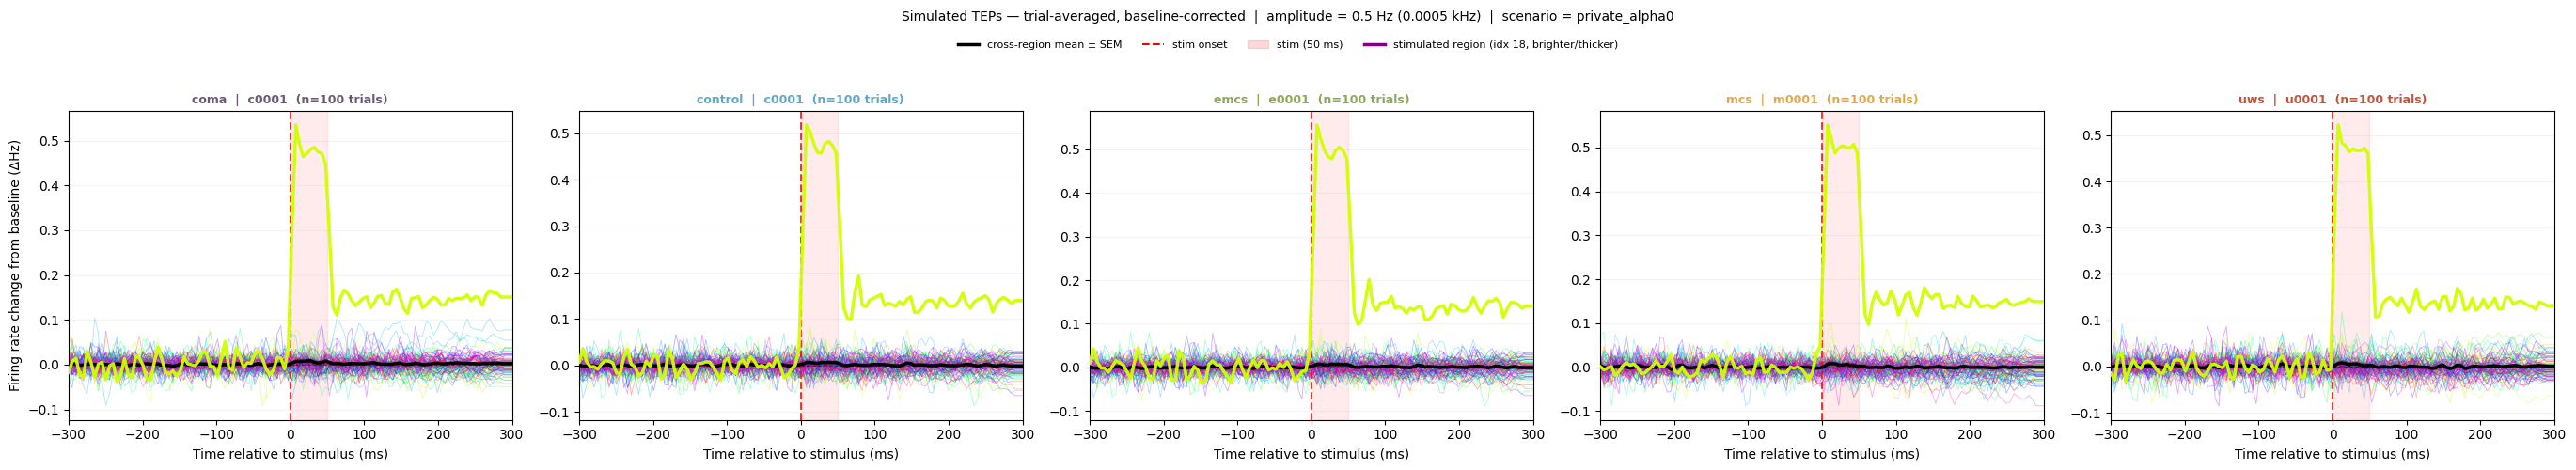


Trials loaded: 100  |  Regions: 90
  stim_amplitude   = 0.0005 kHz = 0.50 Hz
  stim_duration_ms = 50.0 ms
  stim_region      = [18]

What to expect (Casali / Massimini TEP style):
  Pre-stim  (~-300 to 0 ms) → quasi-flat at ΔHz = 0 (noise averages out)
  Post-stim (0 to +300 ms)  → coloured per-region deflections, stimulated
                               region (brighter/thicker) most prominent


In [13]:
# ── Stimulation sanity check — TEP-style per-region rainbow plot ───────────────
# Replicates the empirical/simulated TEP visualisation (Casali / Massimini style):
#   • Each brain region = one coloured trace (HSV rainbow, as in the colour-wheel figure)
#   • Baseline correction: subtract each region's pre-stim mean → pre-stim is flat at 0
#   • Bold black line = cross-region mean (trial-averaged)
#   • Shaded grey = cross-region SEM
#   • Pre-stim should be quasi-flat; post-stim should show deflections per region
#
# Firing rates are in kHz (AdEx E variable) → ×1e3 = Hz → baseline-correct → ΔHz
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np
from pathlib import Path

COHORT_COLORS_SIM = {
    "control": "#5FA7C6",
    "emcs":    "#8EA65E",
    "mcs":     "#E1A84A",
    "uws":     "#C2543D",
    "coma":    "#6B5876",
}

def _load_all_pci_trials(route_dir: Path, scenario_key: str = "private_alpha0") -> "dict | None":
    """Load every available PCI trial NPZ for the first subject of each cohort."""
    results = {}
    pci_root = route_dir / "sims_pci" / scenario_key
    if not pci_root.exists():
        print(f"PCI directory not found: {pci_root}")
        return None
    for cohort_path in sorted(pci_root.iterdir()):
        if not cohort_path.is_dir():
            continue
        cohort = cohort_path.name
        for subj_path in sorted(cohort_path.iterdir()):
            trials = []
            for trial_file in sorted(subj_path.glob("trial_*.npz")):
                d = np.load(trial_file)
                trials.append({
                    "time_ms":          np.asarray(d["time_ms"],  dtype=float),
                    "rate_hz":          np.asarray(d["rate"],     dtype=float) * 1e3,  # kHz→Hz
                    "stim_onset_ms":    float(d["stim_onset_ms"][0]),
                    "t_analysis_ms":    float(d["t_analysis_ms"][0]),
                    "stim_amplitude":   float(d["stim_amplitude"][0]),
                    "stim_duration_ms": float(d["stim_duration_ms"][0]),
                    "stim_region":      d["stim_region"].tolist(),
                })
            if trials:
                results[cohort] = {"trials": trials, "subject_id": subj_path.name}
                break
    return results if results else None

route_dir = ROUTE_A_DIR if RUN_ROUTE in ("A", "both") else ROUTE_B_DIR
pci_data  = _load_all_pci_trials(route_dir)

if not pci_data:
    print("No PCI trial files found yet — run the PCI dispatch cells first.")
else:
    cohorts_found = list(pci_data.keys())
    n_cohorts     = len(cohorts_found)

    fig, axes = plt.subplots(1, n_cohorts, figsize=(5.5 * n_cohorts, 4.5), sharey=False)
    if n_cohorts == 1:
        axes = [axes]

    for ax, cohort in zip(axes, cohorts_found):
        trials   = pci_data[cohort]["trials"]
        subj_id  = pci_data[cohort]["subject_id"]
        n_trials = len(trials)
        stim_dur = trials[0]["stim_duration_ms"]
        stim_reg = trials[0]["stim_region"]
        t_win    = trials[0]["t_analysis_ms"]
        amp_khz  = trials[0]["stim_amplitude"]

        # ── Build common time grid ────────────────────────────────────────────
        dt        = np.median(np.diff(trials[0]["time_ms"]))
        n_bins    = int(round(2 * t_win / dt))
        t_common  = np.linspace(-t_win, t_win, n_bins)   # ms relative to onset

        n_regions = trials[0]["rate_hz"].shape[1]

        # ── Align & average across trials: result shape (n_bins, n_regions) ──
        # Interpolate each trial onto t_common, then stack and mean
        trial_stack = []   # list of (n_bins, n_regions)
        for tr in trials:
            t_rel = tr["time_ms"] - tr["stim_onset_ms"]
            r_aligned = np.column_stack([
                np.interp(t_common, t_rel, tr["rate_hz"][:, reg])
                for reg in range(n_regions)
            ])
            trial_stack.append(r_aligned)

        # Trial-averaged firing rate: (n_bins, n_regions) in Hz
        trial_avg = np.mean(trial_stack, axis=0)

        # ── Baseline correction: subtract each region's pre-stim mean ────────
        pre_mask  = t_common < 0
        baseline  = trial_avg[pre_mask].mean(axis=0)          # (n_regions,)
        r_corr    = trial_avg - baseline[np.newaxis, :]        # ΔHz, centred at 0

        # ── Rainbow colours — one per region (HSV colourmap, like colour wheel) ─
        region_colors = cm.hsv(np.linspace(0, 1, n_regions, endpoint=False))

        # ── Plot individual region traces ─────────────────────────────────────
        for reg in range(n_regions):
            lw    = 2.5 if reg in stim_reg else 0.6
            alpha = 0.95 if reg in stim_reg else 0.35
            zord  = 5   if reg in stim_reg else 2
            ax.plot(t_common, r_corr[:, reg],
                    color=region_colors[reg], lw=lw, alpha=alpha, zorder=zord)

        # ── Cross-region mean ± SEM ───────────────────────────────────────────
        mean_trace = r_corr.mean(axis=1)                        # (n_bins,)
        sem_trace  = r_corr.std(axis=1) / np.sqrt(n_regions)
        ax.fill_between(t_common, mean_trace - sem_trace, mean_trace + sem_trace,
                        color="black", alpha=0.15, zorder=3)
        ax.plot(t_common, mean_trace, color="black", lw=2.5, zorder=4,
                label="cross-region mean ± SEM")

        # ── Baseline reference & stim annotations ────────────────────────────
        ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.4)
        ax.axvline(0, color="red",   lw=1.5, ls="--", alpha=0.8, label="stim onset")
        ax.axvspan(0, stim_dur, color="red", alpha=0.08,
                   label=f"stim ({stim_dur:.0f} ms)")

        ax.set_title(f"{cohort}  |  {subj_id}  (n={n_trials} trials)",
                     fontsize=9, color=COHORT_COLORS_SIM.get(cohort, "gray"),
                     fontweight="bold")
        ax.set_xlabel("Time relative to stimulus (ms)", fontsize=10)
        ax.set_xlim(-t_win, t_win)
        ax.grid(alpha=0.15, axis="y")
        if ax is axes[0]:
            ax.set_ylabel("Firing rate change from baseline (ΔHz)", fontsize=10)

    # ── Shared legend ─────────────────────────────────────────────────────────
    handles = [
        plt.Line2D([0], [0], color="black", lw=2.5,         label="cross-region mean ± SEM"),
        plt.Line2D([0], [0], color="red",   lw=1.5, ls="--",label="stim onset"),
        mpatches.Patch(color="red",         alpha=0.15,
                       label=f"stim ({trials[0]['stim_duration_ms']:.0f} ms)"),
        plt.Line2D([0], [0], color="purple",lw=2.5,
                   label=f"stimulated region (idx {stim_reg[0]}, brighter/thicker)"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=8, frameon=False)

    amp_khz = trials[0]["stim_amplitude"]
    fig.suptitle(
        f"Simulated TEPs — trial-averaged, baseline-corrected  |  "
        f"amplitude = {amp_khz*1e3:.1f} Hz ({amp_khz:.4f} kHz)  |  "
        f"scenario = private_alpha0",
        fontsize=10, y=1.10
    )
    fig.tight_layout()

    out_path = ROUTE_A_DIR / "stim_sanity_check.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved → {out_path}")
    plt.show()

    print(f"\nTrials loaded: {n_trials}  |  Regions: {n_regions}")
    print(f"  stim_amplitude   = {amp_khz:.4f} kHz = {amp_khz*1e3:.2f} Hz")
    print(f"  stim_duration_ms = {stim_dur:.1f} ms")
    print(f"  stim_region      = {stim_reg}")
    print("\nWhat to expect (Casali / Massimini TEP style):")
    print("  Pre-stim  (~-300 to 0 ms) → quasi-flat at ΔHz = 0 (noise averages out)")
    print("  Post-stim (0 to +300 ms)  → coloured per-region deflections, stimulated")
    print("                               region (brighter/thicker) most prominent")


In [14]:
if RUN_ROUTE in ("B", "both"):
    # ── Dispatch Route B PCI trial simulations ────────────────────────────────────
    route_b_pci_results = _dispatch_jobs(
        route_b_pci_jobs,
        run_pci_trial_job,
        desc="Route B | PCI trials",
    )
    
    if route_b_pci_results:
        _df_pci_b = pd.DataFrame(route_b_pci_results)
        print(_df_pci_b[["scenario", "cohort", "subject_id", "trial_seed",
                         "stim_onset_ms", "runtime_s"]].to_string())
else:
    print("[Route B PCI] Skipped (RUN_ROUTE={!r})".format(RUN_ROUTE))


[Route B PCI] Skipped (RUN_ROUTE='A')


## §8  Firing Rate Verification — E and I Population Dynamics

This section checks that simulated firing rates are in the physiologically plausible range
for the AdEx mean-field model in the asynchronous-irregular (AI) state:

| Population | Expected range (Hz) | TVB storage (kHz) | Initial condition |
|------------|--------------------|--------------------|-------------------|
| Excitatory E | 1 – 30 Hz | 0.001 – 0.030 kHz | 0.004 kHz (= 4 Hz) |
| Inhibitory I | 5 – 80 Hz | 0.005 – 0.080 kHz | 0.010 kHz (= 10 Hz) |

> **Why kHz?**  TVB's AdEx model uses kHz as the native unit for the E and I state variables
> (spikes per millisecond).  All NPZ files store rates **in kHz**.  To display in Hz, multiply
> by 1000.  The analysis notebook does this automatically on load.

> **Stimulus amplitude note:**  The original Hugo/Maria stimulus amplitude `0.0005 kHz = 0.5 Hz` is
> a perturbation added *on top of* the ~4–10 Hz resting rate — it is **not** the baseline.
> If spontaneous E readings are consistently ≈ 0.5 Hz you are seeing DOWN-state activity and
> should increase coupling strength or check initial conditions.

The cell below loads the first available NPZ from Route A and plots:
- **Panel A**: Single-region E timeseries for 5 randomly selected regions
- **Panel B**: E amplitude distribution across all regions and time points
- **Panel C**: Where available, PCI trial files are used to estimate I ≈ E × balance ratio

Spontaneous NPZ: /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_sim_v2/private_only/sims/private_alpha0/coma/c0001/seed_000.npz
PCI trial NPZ:   /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_sim_v2/private_only/sims_pci/private_alpha0/coma/c0001/trial_000.npz


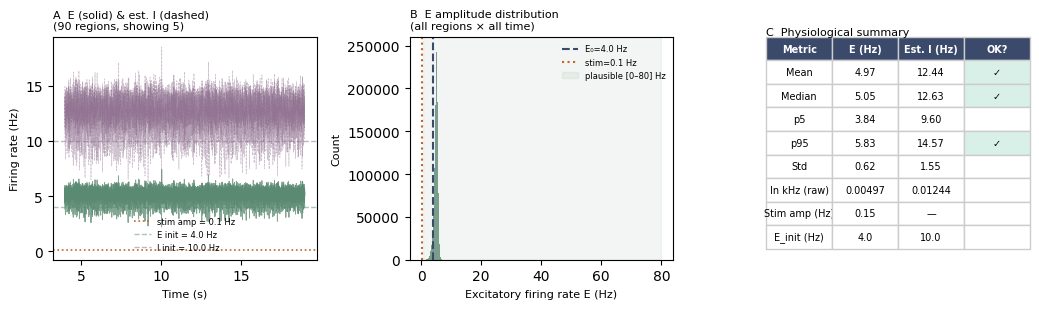


File: seed_000.npz
  Shape: 23600 time points × 90 regions  (dt = 5.0 ms)

  Excitatory E (Hz):
    mean ± std = 4.97 ± 0.62
    median     = 5.05
    p5  / p95  = 3.84 / 5.83
    in kHz     = 0.00497 kHz  (raw NPZ value)

  Stimulus amplitude = 0.0001 kHz = 0.15 Hz
  E initial cond     = 0.0040 kHz = 4.00 Hz
  I initial cond     = 0.0100 kHz = 10.00 Hz
  E/I balance ratio  ≈ 2.50  (I≈2.5×E at rest)

  ✓  Firing rates look physiologically plausible (median E = 5.05 Hz).

  Note: I is estimated as E × 2.50.  For exact I, save variable index 1
        from the TVB rate monitor in run_simulation_only_job.


In [15]:
# ── Firing rate verification — E (and estimated I) ──────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── 1. Find the first available spontaneous NPZ ──────────────────────────────
npz_spont = None
npz_pci   = None
for nd in [ROUTE_A_DIR / "sims", ROUTE_B_DIR / "sims"]:
    if npz_spont:
        break
    for f in sorted(nd.glob("**/*.npz")):
        npz_spont = f
        break
for nd in [ROUTE_A_DIR / "sims_pci", ROUTE_B_DIR / "sims_pci"]:
    if npz_pci:
        break
    for f in sorted(nd.glob("**/*.npz")):
        npz_pci = f
        break

print(f"Spontaneous NPZ: {npz_spont}")
print(f"PCI trial NPZ:   {npz_pci}")

if npz_spont is None and npz_pci is None:
    print("\n⚠  No NPZ files found yet — run the dispatch cells above first.")
    print("   Expected location: outputs/ba_sim_v2/private_only/sims/**/*.npz")
else:
    # ── Determine best available file ────────────────────────────────────────
    use_file = npz_spont if npz_spont else npz_pci
    d = np.load(use_file.resolve() if use_file.is_symlink() else use_file,
                allow_pickle=True)

    # ── Load E (stored in kHz) ────────────────────────────────────────────────
    time_key = "time_rate_ms" if "time_rate_ms" in d else "time_ms"
    time_ms  = np.asarray(d[time_key], dtype=float)
    rate_khz = np.asarray(d["rate"],   dtype=float)   # shape (T, N_regions)
    rate_hz  = rate_khz * 1e3                         # kHz → Hz

    T, N_reg = rate_hz.shape
    dt_ms    = float(np.median(np.diff(time_ms))) if T > 1 else RATE_MONITOR_PERIOD_MS
    t_sec    = time_ms / 1000.0

    # ── Estimated I from balance condition ────────────────────────────────────
    # In the AdEx AI state: I ≈ I_init/E_init × E (preserves ratio from I.C.)
    E_init  = BASE_PARAMETER_MODEL["initial_condition"]["E"][0]   # kHz
    I_init  = BASE_PARAMETER_MODEL["initial_condition"]["I"][0]   # kHz
    EI_ratio = I_init / max(E_init, 1e-9)                         # ≈ 2.5
    estI_hz  = rate_hz * EI_ratio
    # NOTE: this is an approximation — true I varies with network state.
    # For exact I, save variable index 1 from the TVB rate monitor.

    # ── Sanity thresholds ─────────────────────────────────────────────────────
    E_min_ok, E_max_ok = 0.5, 80.0    # Hz
    I_min_ok, I_max_ok = 1.0, 200.0   # Hz

    E_mean = rate_hz.mean()
    E_std  = rate_hz.std()
    E_med  = np.median(rate_hz)
    E_p5   = np.percentile(rate_hz, 5)
    E_p95  = np.percentile(rate_hz, 95)

    ok_E_range = E_p5 > 0.0 and E_p95 < E_max_ok
    ok_E_low   = E_med > E_min_ok

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))

    PHYS_COL   = "#5B8A72"   # sage green = physiological
    STIM_COL   = "#C5622F"   # burnt sienna = stimulus reference
    EST_I_COL  = "#8B6B8B"   # dusty mauve = estimated I

    rng = np.random.default_rng(0)
    show_regs = rng.choice(N_reg, size=min(5, N_reg), replace=False)

    # ─── Panel A: E timeseries for selected regions ───────────────────────────
    ax = axes[0]
    n_show = min(3000, T)
    for reg in show_regs:
        ax.plot(t_sec[:n_show], rate_hz[:n_show, reg],
                lw=0.7, alpha=0.75, color=PHYS_COL)
        ax.plot(t_sec[:n_show], estI_hz[:n_show, reg],
                lw=0.5, alpha=0.40, color=EST_I_COL, ls='--')

    # Reference: stimulus amplitude
    ax.axhline(STIM_AMPLITUDE_PCI * 1e3, color=STIM_COL, lw=1.2, ls=':',
               label=f'stim amp = {STIM_AMPLITUDE_PCI*1e3:.1f} Hz')
    # Reference: initial conditions
    ax.axhline(E_init * 1e3, color=PHYS_COL, lw=1.0, ls='--', alpha=0.5,
               label=f'E init = {E_init*1e3:.1f} Hz')
    ax.axhline(I_init * 1e3, color=EST_I_COL, lw=1.0, ls='--', alpha=0.5,
               label=f'I init = {I_init*1e3:.1f} Hz')

    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('Firing rate (Hz)', fontsize=8)
    ax.set_title(f'A  E (solid) & est. I (dashed)\n({N_reg} regions, showing {len(show_regs)})',
                 fontsize=8, loc='left')
    ax.legend(fontsize=6, frameon=False)

    # ─── Panel B: E distribution ──────────────────────────────────────────────
    ax2 = axes[1]
    flat_E = rate_hz.ravel()
    ax2.hist(flat_E, bins=60, color=PHYS_COL, alpha=0.8, edgecolor='none')
    ax2.axvline(E_init*1e3, color='#3B4A6B', lw=1.5, ls='--', label=f'E₀={E_init*1e3:.1f} Hz')
    ax2.axvline(STIM_AMPLITUDE_PCI*1e3, color=STIM_COL, lw=1.5, ls=':',
                label=f'stim={STIM_AMPLITUDE_PCI*1e3:.1f} Hz')
    ax2.axvspan(E_min_ok, E_max_ok, color='#5B8A72', alpha=0.08,
                label=f'plausible [{E_min_ok:.0f}–{E_max_ok:.0f}] Hz')
    ax2.set_xlabel('Excitatory firing rate E (Hz)', fontsize=8)
    ax2.set_ylabel('Count', fontsize=8)
    ax2.set_title('B  E amplitude distribution\n(all regions × all time)', fontsize=8, loc='left')
    ax2.legend(fontsize=6, frameon=False)

    # ─── Panel C: Statistics summary ─────────────────────────────────────────
    ax3 = axes[2]
    ax3.axis('off')
    rows = [
        ['Metric',          'E (Hz)',            'Est. I (Hz)',          'OK?'],
        ['Mean',            f'{E_mean:.2f}',     f'{E_mean*EI_ratio:.2f}',    '✓' if ok_E_low else '✗ LOW'],
        ['Median',          f'{E_med:.2f}',      f'{E_med*EI_ratio:.2f}',     '✓' if ok_E_low else '✗ LOW'],
        ['p5',              f'{E_p5:.2f}',       f'{E_p5*EI_ratio:.2f}',      ''],
        ['p95',             f'{E_p95:.2f}',      f'{E_p95*EI_ratio:.2f}',     '✓' if ok_E_range else '✗ OOB'],
        ['Std',             f'{E_std:.2f}',      f'{E_std*EI_ratio:.2f}',     ''],
        ['In kHz (raw)',     f'{E_mean/1e3:.5f}', f'{E_mean*EI_ratio/1e3:.5f}',''],
        ['Stim amp (Hz)',    f'{STIM_AMPLITUDE_PCI*1e3:.2f}', '—',            ''],
        ['E_init (Hz)',      f'{E_init*1e3:.1f}', f'{I_init*1e3:.1f}',        ''],
    ]
    tbl = ax3.table(cellText=rows[1:], colLabels=rows[0],
                    cellLoc='center', loc='center',
                    bbox=[0, 0.05, 1, 0.95])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor('#cccccc')
        if r == 0:
            cell.set_facecolor('#3B4A6B')
            cell.get_text().set_color('white')
            cell.get_text().set_fontweight('bold')
        elif c == 3 and r > 0:
            txt = cell.get_text().get_text()
            if '✗' in txt:
                cell.set_facecolor('#fde0d9')
            elif '✓' in txt:
                cell.set_facecolor('#d9f0e8')
    ax3.set_title('C  Physiological summary', fontsize=8, loc='left', pad=0)

    fig.tight_layout()

    out_path = OUT_ROOT / "firing_rate_verification.png"
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    # ── Console summary ───────────────────────────────────────────────────────
    print(f"\nFile: {use_file.name}")
    print(f"  Shape: {T} time points × {N_reg} regions  (dt = {dt_ms:.1f} ms)")
    print(f"\n  Excitatory E (Hz):")
    print(f"    mean ± std = {E_mean:.2f} ± {E_std:.2f}")
    print(f"    median     = {E_med:.2f}")
    print(f"    p5  / p95  = {E_p5:.2f} / {E_p95:.2f}")
    print(f"    in kHz     = {E_mean/1e3:.5f} kHz  (raw NPZ value)")
    print(f"\n  Stimulus amplitude = {STIM_AMPLITUDE_PCI:.4f} kHz = {STIM_AMPLITUDE_PCI*1e3:.2f} Hz")
    print(f"  E initial cond     = {E_init:.4f} kHz = {E_init*1e3:.2f} Hz")
    print(f"  I initial cond     = {I_init:.4f} kHz = {I_init*1e3:.2f} Hz")
    print(f"  E/I balance ratio  ≈ {EI_ratio:.2f}  (I≈{EI_ratio:.1f}×E at rest)")

    if not ok_E_low:
        print(f"\n  ⚠  WARNING: median E = {E_med:.2f} Hz < {E_min_ok} Hz")
        print(f"     Network may be in a near-silent (DOWN) state.")
        print(f"     Consider: increase coupling_strength, check G, or verify kHz→Hz conversion.")
    elif E_med < 2.0:
        print(f"\n  ⚠  NOTE: median E = {E_med:.2f} Hz — low but technically above threshold.")
        print(f"     Typical AI state: 2–20 Hz.  Check if this is expected for your parameters.")
    else:
        print(f"\n  ✓  Firing rates look physiologically plausible (median E = {E_med:.2f} Hz).")
    print(f"\n  Note: I is estimated as E × {EI_ratio:.2f}.  For exact I, save variable index 1")
    print(f"        from the TVB rate monitor in run_simulation_only_job.")


## §7  Output Manifest

The cells below generate a summary of all files written by this notebook.


In [16]:
def _scan_route(route_dir: Path, scenarios: dict, cohort_subjects: dict,
                seed: int, trial_seeds: list) -> dict:
    """Return a dict summarising file presence for a route."""
    spont_found, spont_missing = 0, 0
    pci_found, pci_missing = 0, 0
    for scenario_key in scenarios:
        for cohort, subjects in cohort_subjects.items():
            for subject_id in subjects:
                p = _spont_save_path(route_dir, scenario_key, cohort, subject_id, seed)
                if p.exists():
                    spont_found += 1
                else:
                    spont_missing += 1
                for ts in trial_seeds:
                    pp = _pci_save_path(route_dir, scenario_key, cohort, subject_id, ts)
                    if pp.exists():
                        pci_found += 1
                    else:
                        pci_missing += 1
    return {
        "spontaneous_found":  spont_found,
        "spontaneous_missing": spont_missing,
        "pci_trials_found":   pci_found,
        "pci_trials_missing": pci_missing,
    }


manifest_a = _scan_route(ROUTE_A_DIR, ROUTE_A_SCENARIOS, cohort_subjects,
                          SEED_SPONTANEOUS, PCI_TRIAL_SEEDS)
manifest_b = _scan_route(ROUTE_B_DIR, ROUTE_B_SCENARIOS, cohort_subjects,
                          SEED_SPONTANEOUS, PCI_TRIAL_SEEDS)

manifest_df = pd.DataFrame([
    {"route": "A (private_only)", **manifest_a},
    {"route": "B (full_gamut)",   **manifest_b},
])
print(manifest_df.to_string(index=False))

# Save manifest to disk
manifest_path = OUT_ROOT / "simulation_manifest.json"
manifest_path.write_text(json.dumps({
    "generated_at": datetime.now().isoformat(),
    "route_a": manifest_a,
    "route_b": manifest_b,
    "config": {
        "T_ms":               BASE_PARAMETER_MODEL["T"],
        "transient_ms":       TRANSIENT_MS,
        "spontaneous_sim_ms": SPONTANEOUS_SIM_MS,
        "bold_target_points": BOLD_TARGET_POINTS,
        "enable_bold":        ENABLE_BOLD,
        "rate_monitor_period_ms": RATE_MONITOR_PERIOD_MS,
        "n_trials_pci":       N_TRIALS_PCI,
        "t_analysis_ms_pci":  T_ANALYSIS_MS_PCI,
        "pci_trial_sim_ms":   PCI_TRIAL_SIM_MS,
        "seed_spontaneous":   SEED_SPONTANEOUS,
        "pci_trial_seeds":    PCI_TRIAL_SEEDS,
        "cohorts":            list(COHORTS),
        "route_a_scenarios":  list(ROUTE_A_SCENARIOS),
        "route_b_scenarios":  list(ROUTE_B_SCENARIOS),
    }
}, indent=2))
print(f"\nManifest saved to: {manifest_path}")


           route  spontaneous_found  spontaneous_missing  pci_trials_found  pci_trials_missing
A (private_only)                189                    0             18900                   0
  B (full_gamut)                  0                  945              1000               93500

Manifest saved to: /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_sim_v2/simulation_manifest.json


## Next Steps

Once all simulations are complete, open **`brain_act_full_analysis_v2.ipynb`** to:

1. Load the spontaneous NPZ files from either route
2. Compute LZc (firing rates) and brain states (clustering on phase patterns)
3. Compute multi-trial Casali PCI from the `sims_pci/` trial files
4. Produce publication-quality figures and statistical tables

**Tip:** Point `ROUTE_SELECT` in the analysis notebook to either `"private_only"` or
`"full_gamut"` to analyse the corresponding set of simulations.


In [17]:
print("=" * 60)
print("Simulation notebook complete.")
print(f"  Route A output: {ROUTE_A_DIR}")
print(f"  Route B output: {ROUTE_B_DIR}")
print(f"  Manifest:       {OUT_ROOT / 'simulation_manifest.json'}")
print("=" * 60)
print()
print("Open brain_act_full_analysis_v2.ipynb to run the analysis.")


Simulation notebook complete.
  Route A output: /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_sim_v2/private_only
  Route B output: /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_sim_v2/full_gamut
  Manifest:       /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_sim_v2/simulation_manifest.json

Open brain_act_full_analysis_v2.ipynb to run the analysis.
